In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load your cleaned CSV 
df = pd.read_csv(r"C:\Users\sruth\Documents\Greenbootcamps\Med_Insurance_Finalproject\Data\medical_insurance_clean.csv")
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,bmi_band,age_band
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,2,0,1,0,0,Overweight,45-54
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,1,0,0,1,0,1,1,0,Overweight,65+
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,1,1,0,2,1,0,1,0,Obese I,65+
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,1,0,0,1,0,0,0,Obese I,<25
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,2,0,1,1,0,1,0,Obese I,45-54


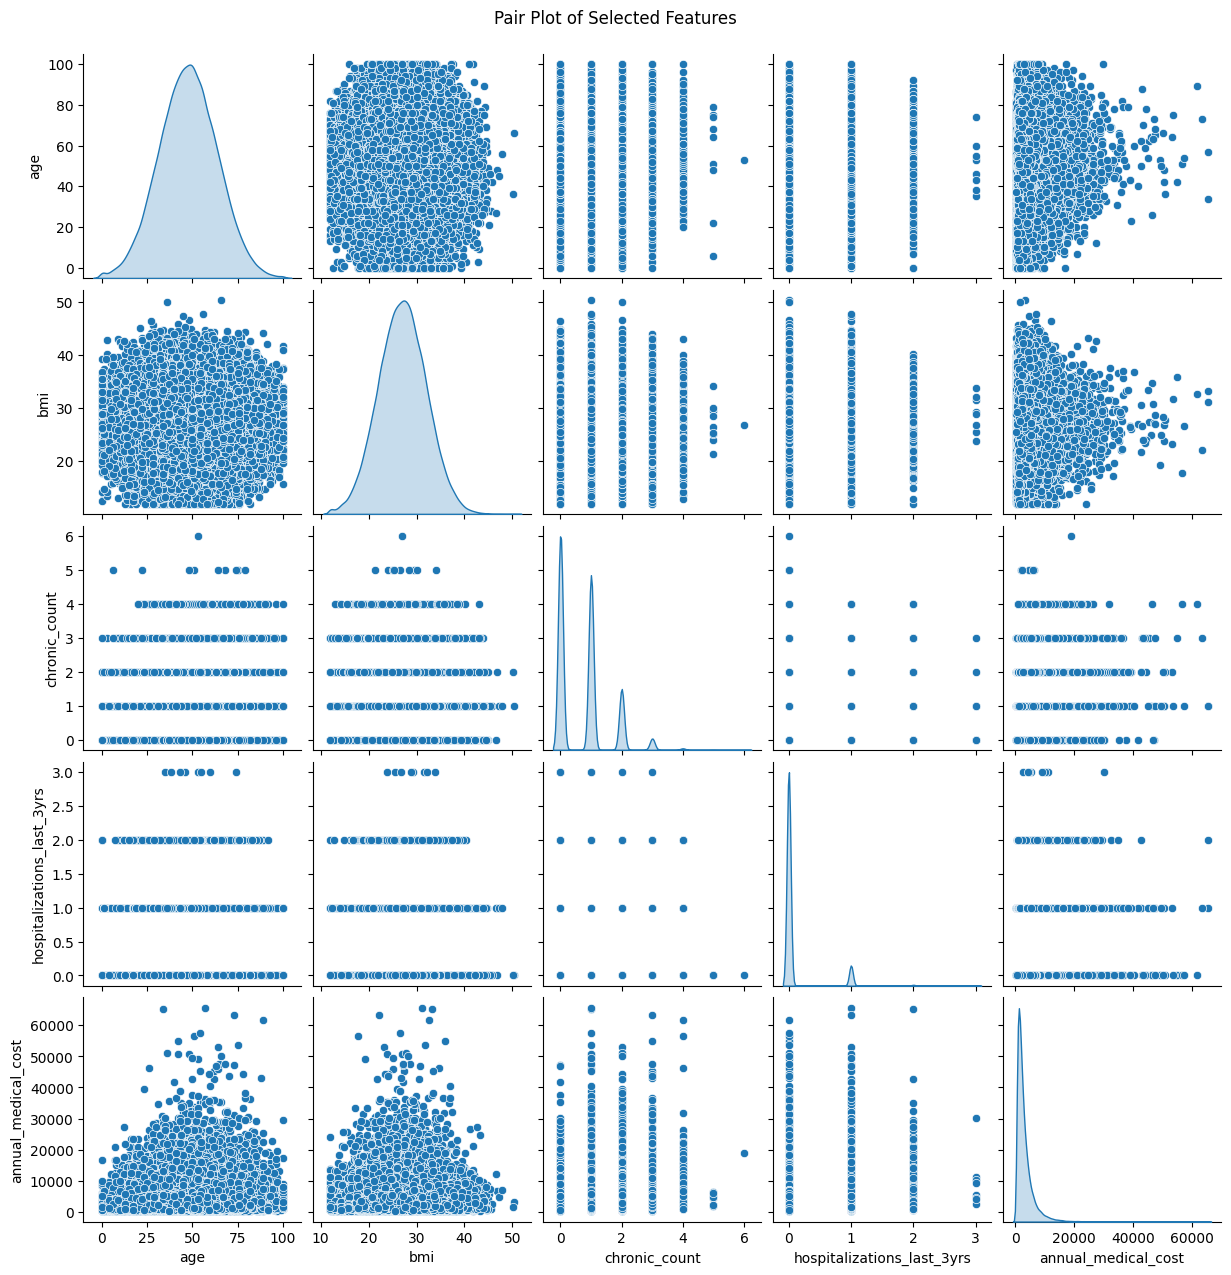

In [5]:
# Pair Plot on a small selection of features to inspect relationships
pairplot_cols = ['age', 'bmi', 'smoker', 'chronic_count', 'hospitalizations_last_3yrs','annual_medical_cost']
if all(col in df.columns for col in pairplot_cols):
    sns.pairplot(df[pairplot_cols], diag_kind='kde')
    plt.suptitle('Pair Plot of Selected Features', y=1.02)
    plt.show()

R2 Score: 0.9664
Mean Squared Error: 330662.8996


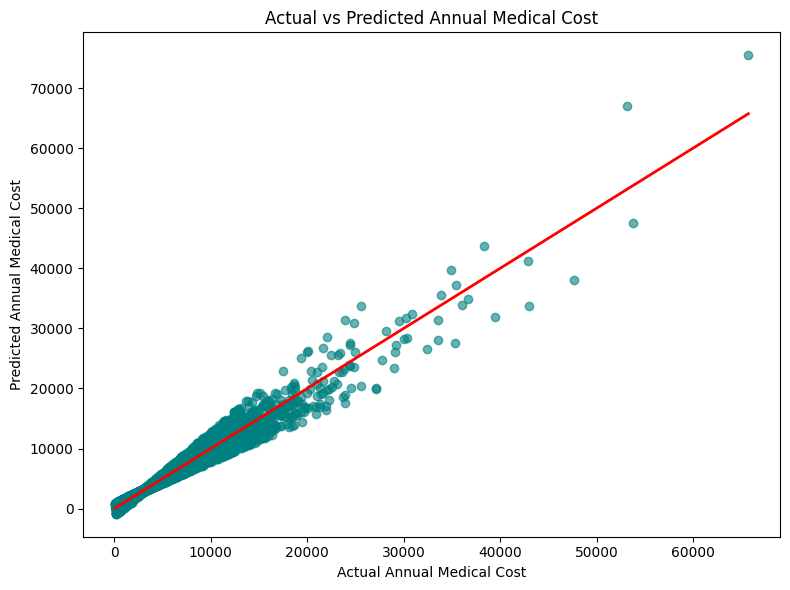

In [6]:
# =====================================================
# MODEL: Predict Annual Medical Cost & Premium (Multi-Output Linear Regression, Standardized)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

# Define the target and feature set
target = 'annual_medical_cost'

# Exclude identifiers and the target from features
exclude_cols = ['person_id', target]
features = df.drop(columns=exclude_cols, errors='ignore')

# Identify categorical and numerical columns from the remaining features
categorical_features = features.select_dtypes(include=['category', 'object']).columns.tolist()
numerical_features = features.select_dtypes(include=[np.number]).columns.tolist()

# One-hot encode categorical variables
features_encoded = pd.get_dummies(features, columns=categorical_features, drop_first=True)

# Define X and y for modeling
X = features_encoded
y = df[target]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'R2 Score: {r2:.4f}')
print(f'Mean Squared Error: {mse:.4f}')

# For visual inspection, plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.xlabel('Actual Annual Medical Cost')
plt.ylabel('Predicted Annual Medical Cost')
plt.title('Actual vs Predicted Annual Medical Cost')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.tight_layout()
plt.show()

Numeric features: 38
Categorical features: 12

📊 Linear Regression — Annual Medical Cost (Leakage-Free)
MAE : 1,430.08
RMSE: 2,348.08
R²  : 0.440
EVS : 0.440


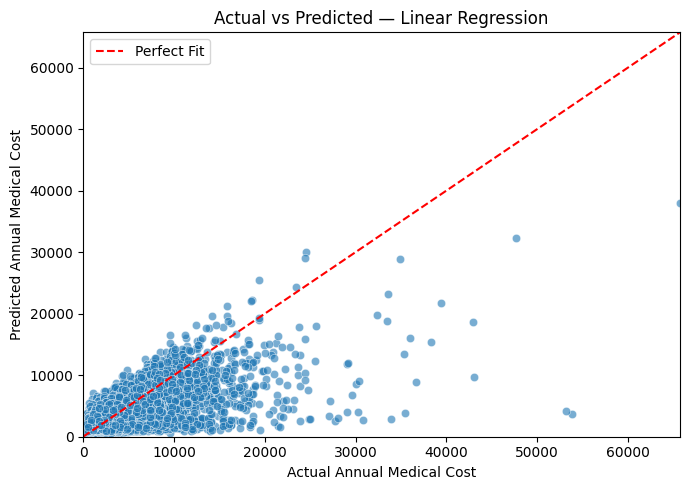

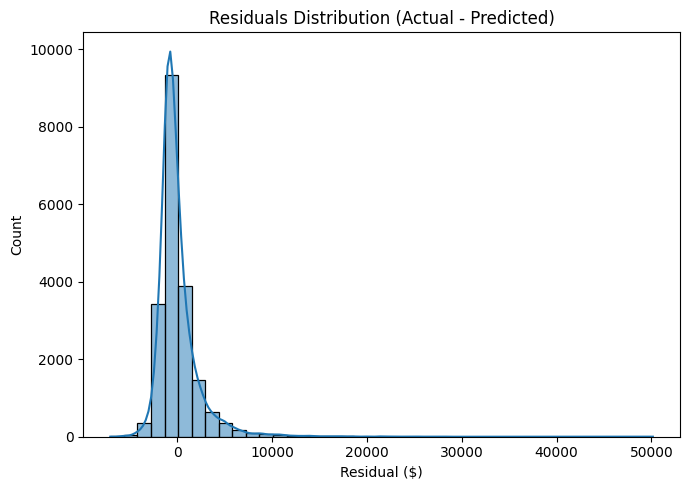


✅ Linear regression training complete (leakage columns removed).


In [4]:
# =====================================================
# MODEL: Predict Annual Medical Cost — Linear Regression (Leakage-Free, Standardized)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

# -----------------------------
# 1) Target & leakage columns
# -----------------------------
target = "annual_medical_cost"
leakage_cols = ['person_id', 'annual_premium', 'monthly_premium',
                'total_claims_paid', 'policy_term_years']

# -----------------------------
# 2) Build X, y (drop leakage)
# -----------------------------
df_model = df.drop(columns=leakage_cols, errors="ignore")
if target not in df_model.columns:
    raise ValueError(f"Target '{target}' not found in dataframe.")

X = df_model.drop(columns=[target], errors="ignore")
y = df_model[target].astype(float)

# -----------------------------
# 3) Identify column types
# -----------------------------
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric features: {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")

# -----------------------------
# 4) Preprocessing
#    - impute medians for numeric, 'unknown' for categoricals
#    - standardize numeric (helps LR)
#    - one-hot encode categoricals
# -----------------------------
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

# -----------------------------
# 5) Model pipeline
# -----------------------------
linreg = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# -----------------------------
# 6) Train / test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 7) Fit & predict
# -----------------------------
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)

# -----------------------------
# 8) Metrics
# -----------------------------
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
evs  = explained_variance_score(y_test, y_pred)

print("\n📊 Linear Regression — Annual Medical Cost (Leakage-Free)")
print("="*60)
print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.3f}")
print(f"EVS : {evs:.3f}")

# -----------------------------
# 9) Plots
# -----------------------------
# Actual vs Predicted
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect Fit')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual Annual Medical Cost")
plt.ylabel("Predicted Annual Medical Cost")
plt.title("Actual vs Predicted — Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()

# Residuals
residuals = y_test - y_pred
plt.figure(figsize=(7,5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residuals Distribution (Actual - Predicted)")
plt.xlabel("Residual ($)")
plt.tight_layout()
plt.show()

print("\n✅ Linear regression training complete (leakage columns removed).")


Numeric features: 40
Categorical features: 12

📊 XGBoost Regression Report — Annual Medical Cost
Mean Absolute Error : 943.60
Root Mean Squared Error : 1,904.75
R² Score : 0.631
Explained Variance : 0.643

Cross-validated R² mean = 0.657 ± 0.002


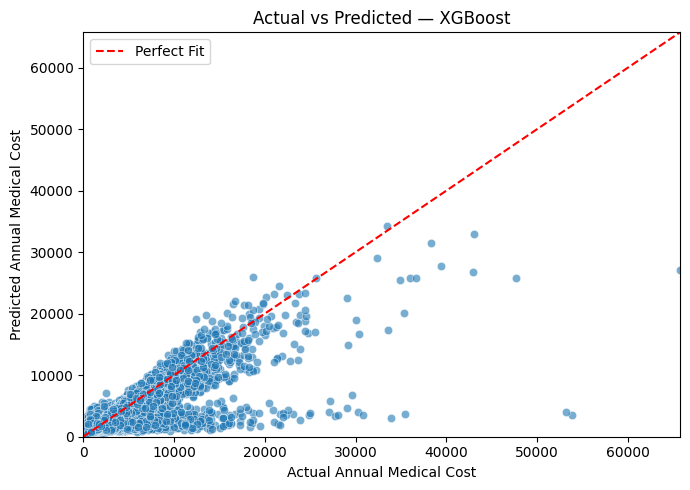

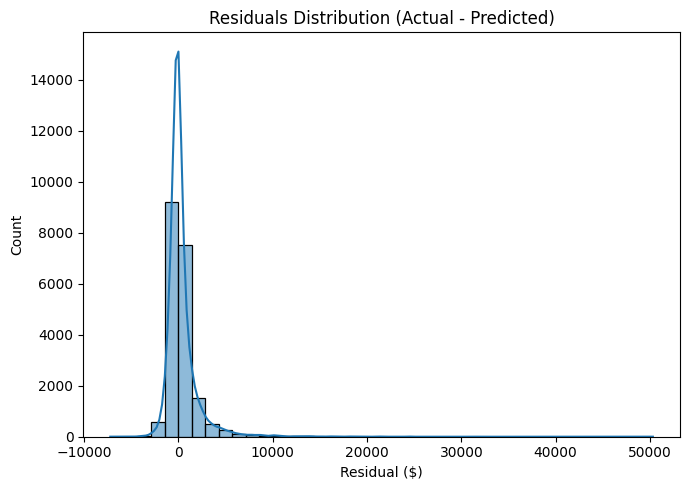

C:\Users\sruth\AppData\Local\Temp\ipykernel_42600\2208317767.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(20), y='Feature', x='Importance', palette='viridis')


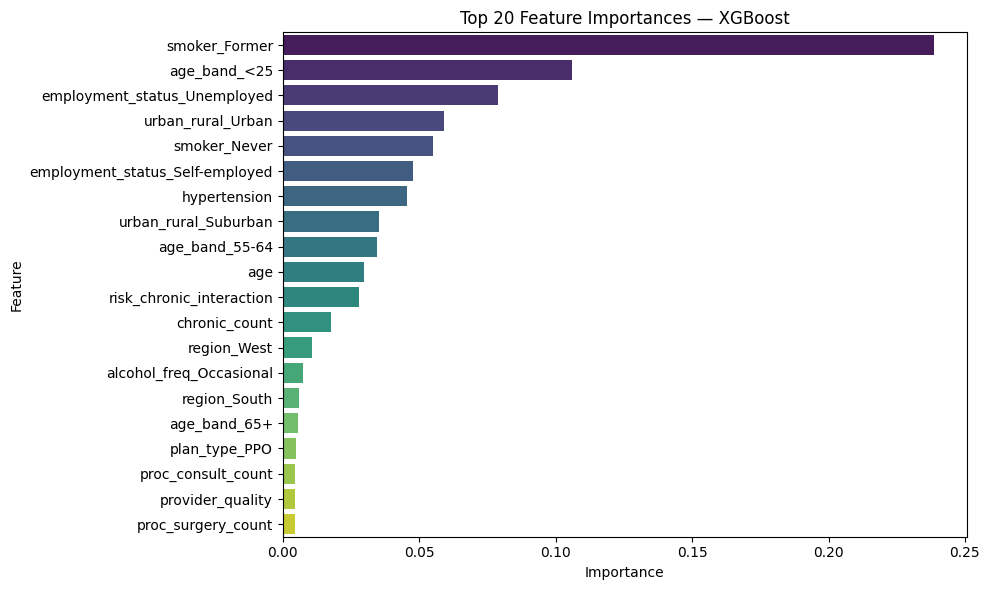


✅ XGBoost model training complete (fast + accurate).


In [5]:
# =====================================================
# MODEL: Predict Annual Medical Cost (XGBoost Regressor)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

from xgboost import XGBRegressor

# -------------------------------------------
# 1. Target and features
# -------------------------------------------
target = "annual_medical_cost"

leakage_cols = ['person_id', 'annual_premium', 'monthly_premium', 
                'total_claims_paid', 'policy_term_years']
df_model = df.drop(columns=leakage_cols, errors='ignore')

X = df_model.drop(columns=[target], errors='ignore')
y = df_model[target]

# -------------------------------------------
# 2. Feature engineering (light)
# -------------------------------------------
if 'risk_score' in X.columns and 'chronic_count' in X.columns:
    X['risk_chronic_interaction'] = X['risk_score'] * X['chronic_count']

if 'claims_count' in X.columns and 'visits_last_year' in X.columns and 'utilization_rate' not in X.columns:
    X['utilization_rate'] = X['claims_count'] / (X['visits_last_year'] + 1)

# -------------------------------------------
# 3. Column types
# -------------------------------------------
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

# -------------------------------------------
# 4. Preprocessing
# -------------------------------------------
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_cols),
    ('cat', cat_pipe, categorical_cols)
])

# -------------------------------------------
# 5. Log-transform target (reduces skew)
# -------------------------------------------
y_log = np.log1p(y)

# -------------------------------------------
# 6. Train-test split
# -------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# -------------------------------------------
# 7. XGBoost model
# -------------------------------------------
xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    random_state=42,
    n_jobs=-1
)

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb)
])

# -------------------------------------------
# 8. Train
# -------------------------------------------
xgb_model.fit(X_train, y_train)

# -------------------------------------------
# 9. Predict (inverse log)
# -------------------------------------------
y_pred_log = xgb_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

# -------------------------------------------
# 10. Evaluation
# -------------------------------------------
mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)
evs = explained_variance_score(y_actual, y_pred)

print("\n📊 XGBoost Regression Report — Annual Medical Cost")
print("="*60)
print(f"Mean Absolute Error : {mae:,.2f}")
print(f"Root Mean Squared Error : {rmse:,.2f}")
print(f"R² Score : {r2:.3f}")
print(f"Explained Variance : {evs:.3f}")

# -------------------------------------------
# 11. Cross-validation
# -------------------------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(xgb_model, X, y_log, cv=cv, scoring='r2', n_jobs=-1)
print(f"\nCross-validated R² mean = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")

# -------------------------------------------
# 12. Visualizations
# -------------------------------------------
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_actual, y=y_pred, alpha=0.6)
lims = [0, max(y_actual.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect Fit')
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Actual Annual Medical Cost")
plt.ylabel("Predicted Annual Medical Cost")
plt.title("Actual vs Predicted — XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_actual - y_pred
plt.figure(figsize=(7,5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residuals Distribution (Actual - Predicted)")
plt.xlabel("Residual ($)")
plt.tight_layout()
plt.show()

# -------------------------------------------
# 13. Feature Importance
# -------------------------------------------
booster = xgb_model.named_steps['regressor']
encoded_features = list(
    xgb_model.named_steps['preprocessor']
    .transformers_[1][1]
    .named_steps['encoder']
    .get_feature_names_out(categorical_cols)
) + numeric_cols

importances = booster.feature_importances_
fi_df = pd.DataFrame({'Feature': encoded_features, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=fi_df.head(20), y='Feature', x='Importance', palette='viridis')
plt.title("Top 20 Feature Importances — XGBoost")
plt.tight_layout()
plt.show()

print("\n✅ XGBoost model training complete (fast + accurate).")


In [6]:
!pip install --upgrade xgboost

In [4]:
import xgboost
print(xgboost.__version__)


3.1.1


Training rows after winsorization: 98,000 (kept 98.0% of data)
Numeric features: 30 | Categorical features: 10

📊 XGBoost — Annual Medical Cost (Native API)
MAE  : 1,508.59
RMSE : 2,338.38
R²   : 0.089
EVS  : 0.164
Best iteration : 113


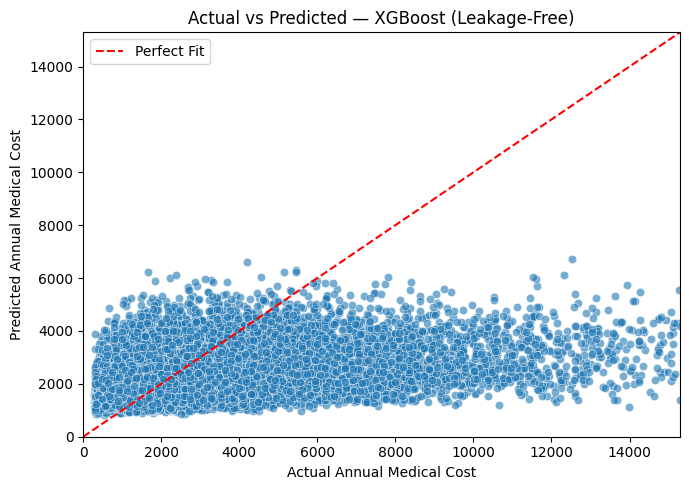

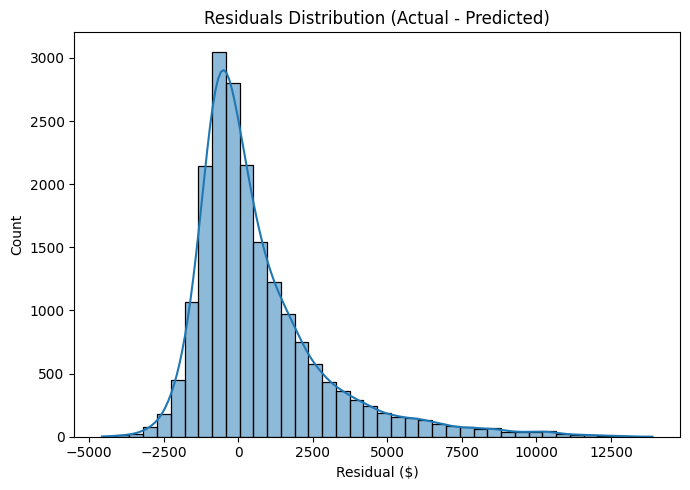

C:\Users\sruth\AppData\Local\Temp\ipykernel_42600\1842228328.py:289: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df.head(20), y="Feature", x="Importance", orient="h", palette="viridis")


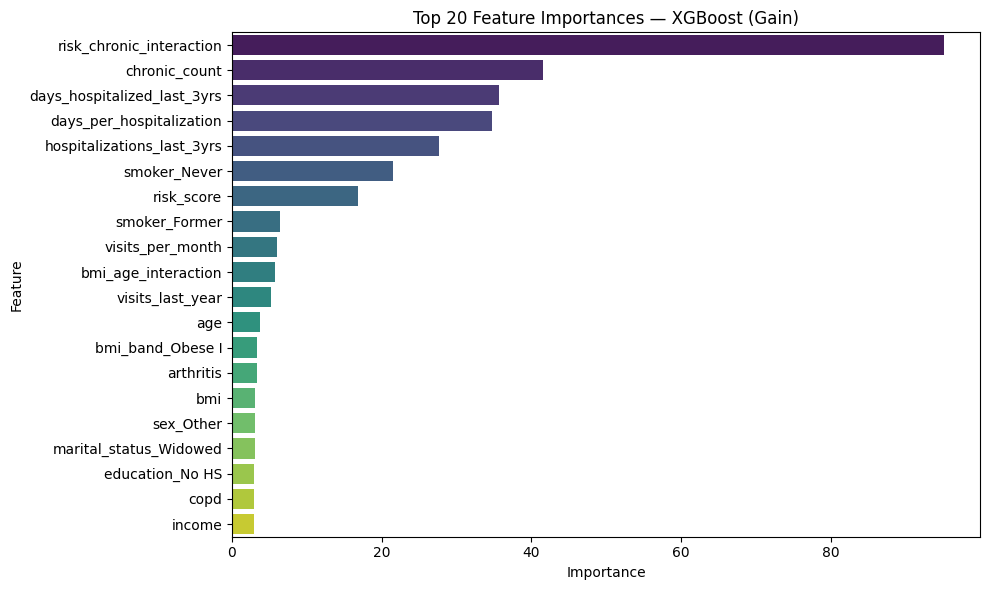


Top 15 features by 'gain':
                    Feature  Importance
   risk_chronic_interaction   95.162796
              chronic_count   41.491947
days_hospitalized_last_3yrs   35.662647
   days_per_hospitalization   34.750900
 hospitalizations_last_3yrs   27.687557
               smoker_Never   21.539011
                 risk_score   16.805868
              smoker_Former    6.455299
           visits_per_month    5.981752
        bmi_age_interaction    5.788269
           visits_last_year    5.287061
                        age    3.793777
           bmi_band_Obese I    3.373546
                  arthritis    3.351686
                        bmi    3.126511

✅ Saved preprocessor    → cost_preprocessor.pkl
✅ Saved SAFE feat names → cost_feature_names_safe.pkl
✅ Saved ORIG feat names → cost_feature_names_orig.pkl
✅ Saved name map        → cost_feature_name_map.pkl
✅ Saved model           → cost_xgb_native.json


In [7]:
# =====================================================
# Annual Medical Cost — XGBoost (Native API, Early Stop, Safe FE, No Leakage)
# =====================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, explained_variance_score

from xgboost import DMatrix, train as xgb_train, Booster
import joblib

# -----------------------------
# Config
# -----------------------------
TARGET = "annual_medical_cost"

# 🔒 Expanded leakage columns: IDs, plan/pricing, claims/procedures, admin/post-outcome
LEAKAGE_COLS = [
    # IDs
    "person_id",
    # Plan / pricing / admin
    "plan_type", "network_tier", "annual_premium", "monthly_premium",
    "deductible", "copay", "policy_term_years", "policy_changes_last_2yrs",
    "provider_quality", "is_high_risk", "had_major_procedure",
    # Realized claims / procedures
    "total_claims_paid", "avg_claim_amount", "claims_count",
    "proc_imaging_count", "proc_surgery_count", "proc_physio_count",
    "proc_consult_count", "proc_lab_count",
]

USE_IN_MEMORY_DF = True
CSV_PATH = r"C:\path\to\medical_insurance_clean.csv"

WINSORIZE_Q = (0.01, 0.99)  # trim 1% tails
MODEL_OUT = "cost_xgb_native.json"
PREP_OUT  = "cost_preprocessor.pkl"
FEATS_SAFE_OUT = "cost_feature_names_safe.pkl"
FEATS_ORIG_OUT = "cost_feature_names_orig.pkl"
NAME_MAP_OUT   = "cost_feature_name_map.pkl"

# -----------------------------
# Helpers
# -----------------------------
def add_features(Xdf: pd.DataFrame) -> pd.DataFrame:
    """
    Light, leakage-safe feature engineering (pre-quote only).
    Uses ONLY variables known before the prediction period.
    """
    Xd = Xdf.copy()

    # Safe interactions
    if {"risk_score", "chronic_count"}.issubset(Xd.columns):
        Xd["risk_chronic_interaction"] = Xd["risk_score"] * Xd["chronic_count"]
    if {"bmi", "age"}.issubset(Xd.columns):
        Xd["bmi_age_interaction"] = Xd["bmi"] * Xd["age"]

    # Prior-period utilization ONLY (no claims_count / premiums / deductible / copay)
    if "visits_last_year" in Xd.columns:
        Xd["visits_per_month"] = Xd["visits_last_year"] / 12.0
    if "hospitalizations_last_3yrs" in Xd.columns:
        Xd["hosp_intensity"] = Xd["hospitalizations_last_3yrs"] / 3.0
    if {"days_hospitalized_last_3yrs","hospitalizations_last_3yrs"}.issubset(Xd.columns):
        Xd["days_per_hospitalization"] = (
            Xd["days_hospitalized_last_3yrs"] / (Xd["hospitalizations_last_3yrs"] + 1)
        )
    return Xd

FORBIDDEN = r"[\[\]<>]"  # XGBoost forbids [, ], <
def sanitize_names(names):
    """Return (safe_names, name_map) where safe_names are unique strings without forbidden chars."""
    safe = []
    used = set()
    name_map = {}
    for n in names:
        s = str(n)
        s = re.sub(FORBIDDEN, "_", s)
        s = (s.replace("(", "_").replace(")", "_")
               .replace("{", "_").replace("}", "_")
               .replace("=", "_").replace(" ", "_")
               .replace(",", "_").replace(":", "_")
               .replace("/", "_"))
        while "__" in s:
            s = s.replace("__", "_")
        s = s.strip("_") or "feat"
        base = s
        k = 1
        while s in used:
            k += 1
            s = f"{base}_{k}"
        used.add(s)
        safe.append(s)
        name_map[s] = str(n)
    return safe, name_map

def normalize_for_sklearn(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replace pandas NA with numpy nan and fix dtypes sklearn can handle.
    - Nullable integers (Int64) -> float64 if NaN present
    - Pandas nullable booleans ('boolean') -> object
    - Pandas 'string' dtype -> object
    """
    out = df.copy()
    out = out.replace({pd.NA: np.nan})
    for c in out.columns:
        dt = out[c].dtype
        if pd.api.types.is_integer_dtype(dt) and out[c].isna().any():
            out[c] = out[c].astype("float64")
        if str(dt) == "boolean":
            out[c] = out[c].astype(object)
        if str(dt) == "string":
            out[c] = out[c].astype(object)
    out = out.replace({pd.NA: np.nan})
    return out

# -----------------------------
# 0) Load data
# -----------------------------
if USE_IN_MEMORY_DF:
    try:
        df_model = df.copy()  # expects a df already in memory
    except NameError:
        raise RuntimeError("Set USE_IN_MEMORY_DF=False or define a DataFrame named `df` first.")
else:
    df_model = pd.read_csv(CSV_PATH)

# Global normalization to avoid pd.NA issues
df_model = normalize_for_sklearn(df_model)

# -----------------------------
# 1) Drop leakage & build X, y
# -----------------------------
df_model = df_model.drop(columns=LEAKAGE_COLS, errors="ignore")
if TARGET not in df_model.columns:
    raise ValueError(f"Target `{TARGET}` not found.")
y_raw = df_model[TARGET].copy()
X_raw = df_model.drop(columns=[TARGET], errors="ignore")

# -----------------------------
# 2) Winsorize target (reduce outlier distortion)
# -----------------------------
lo, hi = y_raw.quantile(WINSORIZE_Q)
mask = (y_raw >= lo) & (y_raw <= hi)
X = X_raw.loc[mask].reset_index(drop=True)
y = y_raw.loc[mask].reset_index(drop=True)
print(f"Training rows after winsorization: {len(y):,} (kept {mask.mean():.1%} of data)")

# -----------------------------
# 3) Leakage-safe feature engineering
# -----------------------------
X = add_features(X)
X = normalize_for_sklearn(X)  # ensure engineered columns are normalized too

# -----------------------------
# 4) Column types
# -----------------------------
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features: {len(num_cols)} | Categorical features: {len(cat_cols)}")

# -----------------------------
# 5) Preprocessor (impute + OHE)
# -----------------------------
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first")),
])
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

# -----------------------------
# 6) Log-transform target
# -----------------------------
y_log = np.log1p(y)

# -----------------------------
# 7) Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

# -----------------------------
# 8) Fit preprocessor + transform
# -----------------------------
preprocessor.fit(X_tr)
Xtr  = preprocessor.transform(X_tr)
Xval = preprocessor.transform(X_val)
Xte  = preprocessor.transform(X_test)

# Build original feature names in transformer output order: [num..., encoded cat...]
ohe = preprocessor.named_transformers_["cat"].named_steps["ohe"] if len(cat_cols) else None
encoded_cat = ohe.get_feature_names_out(cat_cols).tolist() if ohe is not None else []
FEATURE_NAMES_ORIG = [str(f) for f in list(num_cols)] + [str(f) for f in encoded_cat]

# Sanitize for XGBoost (no [, ], <) and ensure uniqueness
FEATURE_NAMES_SAFE, NAME_MAP = sanitize_names(FEATURE_NAMES_ORIG)

# -----------------------------
# 9) Train XGBoost (native API) with early stopping
# -----------------------------
params = {
    "learning_rate": 0.035,
    "max_depth": 7,
    "min_child_weight": 4,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "gamma": 0.2,
    "reg_lambda": 1.0,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "random_state": 42
}

dtrain = DMatrix(Xtr,  label=y_tr,  feature_names=FEATURE_NAMES_SAFE)
dvalid = DMatrix(Xval, label=y_val, feature_names=FEATURE_NAMES_SAFE)
dtest  = DMatrix(Xte,  feature_names=FEATURE_NAMES_SAFE)

bst = xgb_train(
    params=params,
    dtrain=dtrain,
    num_boost_round=900,
    evals=[(dtrain, "train"), (dvalid, "eval")],
    early_stopping_rounds=30,
    verbose_eval=False
)

# -----------------------------
# 10) Predict & evaluate
# -----------------------------
y_pred_log = bst.predict(dtest)
y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

mae  = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2   = r2_score(y_actual, y_pred)
evs  = explained_variance_score(y_actual, y_pred)

print("\n📊 XGBoost — Annual Medical Cost (Native API)")
print("="*60)
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.3f}")
print(f"EVS  : {evs:.3f}")
print(f"Best iteration : {getattr(bst, 'best_iteration', None) + 1 if hasattr(bst, 'best_iteration') else 'n/a'}")

# -----------------------------
# 11) Plots
# -----------------------------
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_actual, y=y_pred, alpha=0.6)
lims = [0, max(y_actual.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect Fit")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual Annual Medical Cost"); plt.ylabel("Predicted Annual Medical Cost")
plt.title("Actual vs Predicted — XGBoost (Leakage-Free)")
plt.legend(); plt.tight_layout(); plt.show()

residuals = y_actual - y_pred
plt.figure(figsize=(7,5))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residuals Distribution (Actual - Predicted)")
plt.xlabel("Residual ($)")
plt.tight_layout(); plt.show()

# -----------------------------
# 12) Feature importances (gain)
# -----------------------------
importance = bst.get_score(importance_type="gain")  # dict: {safe_name: score}
imp_df = (pd.DataFrame({"SafeFeature": list(importance.keys()),
                        "Importance": list(importance.values())})
          .sort_values("Importance", ascending=False))
rev_map = {safe: orig for safe, orig in sanitize_names(FEATURE_NAMES_ORIG)[1].items()}  # name map from this session
imp_df["Feature"] = imp_df["SafeFeature"].map({k:v for k,v in zip(FEATURE_NAMES_SAFE, FEATURE_NAMES_ORIG)}).fillna(imp_df["SafeFeature"])

plt.figure(figsize=(10,6))
sns.barplot(data=imp_df.head(20), y="Feature", x="Importance", orient="h", palette="viridis")
plt.title("Top 20 Feature Importances — XGBoost (Gain)")
plt.tight_layout(); plt.show()

print("\nTop 15 features by 'gain':")
print(imp_df[["Feature", "Importance"]].head(15).to_string(index=False))

# -----------------------------
# 13) Save artifacts
# -----------------------------
joblib.dump(preprocessor, PREP_OUT)
joblib.dump(FEATURE_NAMES_SAFE, FEATS_SAFE_OUT)  # list[str]
joblib.dump(FEATURE_NAMES_ORIG, FEATS_ORIG_OUT)  # list[str]
joblib.dump({s:o for s,o in zip(FEATURE_NAMES_SAFE, FEATURE_NAMES_ORIG)}, NAME_MAP_OUT)  # dict safe->orig
bst.save_model(MODEL_OUT)
print(f"\n✅ Saved preprocessor    → {PREP_OUT}")
print(f"✅ Saved SAFE feat names → {FEATS_SAFE_OUT}")
print(f"✅ Saved ORIG feat names → {FEATS_ORIG_OUT}")
print(f"✅ Saved name map        → {NAME_MAP_OUT}")
print(f"✅ Saved model           → {MODEL_OUT}")

# -----------------------------
# 14) Helper: predict for new rows (with debug)
# -----------------------------
def _expected_raw_cols_from_preprocessor(prep: ColumnTransformer):
    """Return (num_cols, cat_cols) in train-time order from a fitted preprocessor."""
    try:
        num_cols = list(prep.transformers_[0][2])
        cat_cols = list(prep.transformers_[1][2])
    except Exception:
        num_cols = list(prep.named_transformers_["num"].feature_names_in_)
        cat_cols = list(prep.named_transformers_["cat"].feature_names_in_)
    return num_cols, cat_cols

def _build_row_for_missing(raw_df: pd.DataFrame, num_cols, cat_cols) -> pd.DataFrame:
    """Ensure all expected columns exist and are ordered."""
    all_cols = list(num_cols) + list(cat_cols)
    for c in all_cols:
        if c not in raw_df.columns:
            raw_df[c] = np.nan
    return raw_df[all_cols]

def predict_cost_for_df(raw_df: pd.DataFrame) -> np.ndarray:
    """
    Predict annual medical cost for new customer(s).
    raw_df may have a subset/superset of raw columns; we align and impute.
    """
    prep: ColumnTransformer = joblib.load(PREP_OUT)
    feat_safe = joblib.load(FEATS_SAFE_OUT)  # list[str]

    # Normalize NA markers and dtypes, add leakage-safe FE
    Xfe = add_features(raw_df.copy())
    Xfe = normalize_for_sklearn(Xfe)

    # Enforce expected schema and order
    num_cols, cat_cols = _expected_raw_cols_from_preprocessor(prep)
    Xfe = _build_row_for_missing(Xfe, num_cols, cat_cols)

    # Basic dtype sanity
    if len(num_cols):
        Xfe[num_cols] = Xfe[num_cols].apply(pd.to_numeric, errors="coerce")
    for c in cat_cols:
        Xfe[c] = Xfe[c].astype(object)

    # 🔎 Debug: how sparse is the input?
    all_expected = set(num_cols) | set(cat_cols)
    missing = list(all_expected - set(Xfe.columns))
    nan_rate = float(Xfe.isna().mean().mean())
    print(f"[DEBUG] Missing expected cols: {len(missing)} | Mean NaN rate before imputation: {nan_rate:.2%}")
    print(f"[DEBUG] Sample row to model:\n{Xfe.head(1).T}")

    # Transform and predict
    Xenc = prep.transform(Xfe)
    dnew = DMatrix(Xenc, feature_names=feat_safe)
    booster = Booster()
    booster.load_model(MODEL_OUT)
    y_log = booster.predict(dnew)
    return np.expm1(y_log)
